# 02 — STFT & Spectrogram Visualization

Compute and plot log-STFT spectrogram.

In [1]:
from pathlib import Path
import json
import importlib
import matplotlib.pyplot as plt
import torch

import dataset
import fe

# Force refresh to avoid stale notebook kernel cache.
importlib.reload(dataset)
importlib.reload(fe)

SPLIT_JSON = Path("./splits/split_seed42.json")

# Prefer dataset_root recorded in split json to avoid manual path mismatch.
split_info = json.loads(SPLIT_JSON.read_text(encoding="utf-8"))
DATASET_ROOT = Path(split_info.get("dataset_root", "./data/ravdess"))

audio_cfg = dataset.AudioConfig(target_sr=16000, clip_seconds=3.0)
ds = dataset.RAVDESSpeakerID(DATASET_ROOT, SPLIT_JSON, "train", audio_cfg, is_train=True)

wav, y, meta = ds[0]
wav = wav.unsqueeze(0)  # [1,1,T]
print("DATASET_ROOT:", DATASET_ROOT)
print("wav:", wav.shape, "label:", y, "meta:", meta)

STFTConfig = fe.STFTConfig
STFTSpectrogram = fe.STFTSpectrogram



DATASET_ROOT: C:\Users\zhuxitong\Desktop\homework_student\data\ravdess
wav: torch.Size([1, 1, 48000]) label: 0 meta: {'modality': '03', 'modality_str': 'audio-only', 'vocal_channel': '01', 'vocal_channel_str': 'speech', 'emotion': '06', 'emotion_str': 'fearful', 'intensity': '01', 'statement': '02', 'repetition': '01', 'actor': '01'}


c:\Users\zhuxitong\Desktop\homework_student\dataset.py:182: WavFileWarning: Chunk (non-data) not understood, skipping it.
  sr, wav_np = wavfile.read(str(wav_path))


spec: torch.Size([1, 1, 257, 301])


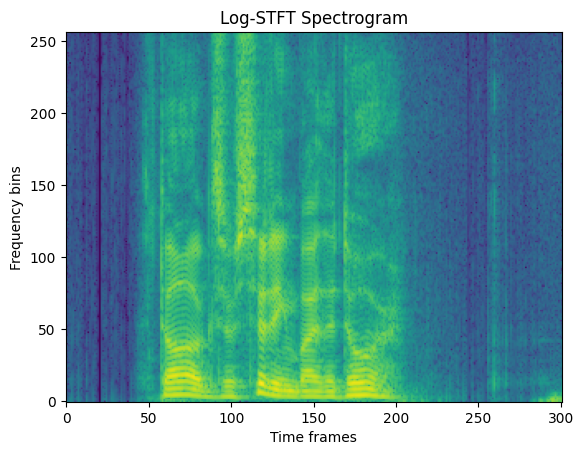

In [2]:
ablation_cfgs = [
    STFTConfig(n_fft=512, win_length=400, hop_length=160),   # baseline
    STFTConfig(n_fft=400, win_length=320, hop_length=160),
    STFTConfig(n_fft=1024, win_length=640, hop_length=320),
]

fig, axes = plt.subplots(1, len(ablation_cfgs), figsize=(5 * len(ablation_cfgs), 4))
if len(ablation_cfgs) == 1:
    axes = [axes]

for ax, cfg in zip(axes, ablation_cfgs):
    fe = STFTSpectrogram(cfg)
    spec = fe(wav)  # [1,1,F,TT]
    ax.imshow(spec[0, 0].detach().cpu().numpy(), aspect="auto", origin="lower")
    ax.set_title(f"n_fft={cfg.n_fft}, win={cfg.win_length}, hop={cfg.hop_length}")
    ax.set_xlabel("Time frames")
    ax.set_ylabel("Frequency bins")
    print("spec:", spec.shape, cfg)

plt.tight_layout()
plt.show()
